In [1]:
import json
import logging
import numpy as np
import pandas as pd
from cmdstanpy import CmdStanModel
from plotnine import *

# quiet down Stan
logger = logging.getLogger("cmdstanpy")
logger.addHandler(logging.NullHandler())

# seed pseudo-rng for repeatability of data generation
# Stan uses its own seeds and state
rng = np.random.default_rng(2026)

# define directories
datadir = "data/"
standir = "stan_models/"
stan_datadir = "stan_data/"


# Who's the best batter? Estimating probabilities with unevenly collected data

In this article, we look at the problem of estimating and comparing probabilities about a population of subjects when the observations of these subjects have been collected unevenly. Some examples might include:

* The perceived quality of a movie (how often is a movie positively reviewed) when some movies have far more reviews than others,
* The effectiveness of various ad campaigns, when some compaigns have had more exposure than others,
* The efficacy of a certain medical procedure by hospital, when some hospitals have had more cases than others.

For our specific task, we'll try to estimate the "innate" batting ability (the probability of making a hit when at bat)[^1] of major league baseball players in 2023[^2]. For the sake of this article, we will take this single season of data as everything that we know about these players and their batting statistics.

First, let's take a quick look at the data.

[^1]: By *innate*, I don't mean some kind of "natural-born" ability; a player's batting ability is no doubt honed by training and practice. I merely use the word *innate* to underline that the probability of a given player making a hit when at bat is not necessarily the same as the *observed* rate at which they made hits during a season.

[^2]: Data from the [Lahman Baseball Database](https://sabr.org/lahman-database/), currently available from the Society for American Baseball Research (SABR). The [Lahman R package](https://cdalzell.github.io/Lahman/) provides an R interface to the database, as well.

In [2]:
battingf = pd.read_csv(datadir + 'battingstats.tsv', sep = "\t")
battingf

,playerID,atbat,hits,batting_avg
0,abramcj01,563,138,0.245115
1,abreujo02,540,128,0.237037
2,abreuwi02,76,24,0.315789
3,acunaro01,643,217,0.337481
4,adamewi01,553,120,0.216998
...,...,...,...,...
651,yoshima02,537,155,0.288641
652,youngja02,43,8,0.186047
653,youngja03,107,27,0.252336
654,zavalse01,175,30,0.171429


In [3]:
nplayers = battingf.shape[0]
print(f'Population of {nplayers} players.')

mean_ba = battingf['batting_avg'].mean()
std_ba = battingf['batting_avg'].std()
print(f'Mean batting average: {mean_ba:.2f}, standard deviation {std_ba:.2f}')

mean_atbat = battingf['atbat'].mean()
std_atbat = battingf['atbat'].std()
print(f'Mean at bats: {mean_atbat:.2f}, standard deviation {std_atbat:.2f}')

Population of 656 players.
Mean batting average: 0.23, standard deviation 0.07
Mean at bats: 250.64, standard deviation 192.45


Given this information, how do we estimate players' batting ability? 

You may be tempted to simply use a player's observed batting average as an estimate of their batting skill. One issue with this is that not all players get the same number of at-bats. Let's look at the batting averages for all the players, sorted by their number of times at bat. The horizontal line on the graph represents the mean batting average of the population.

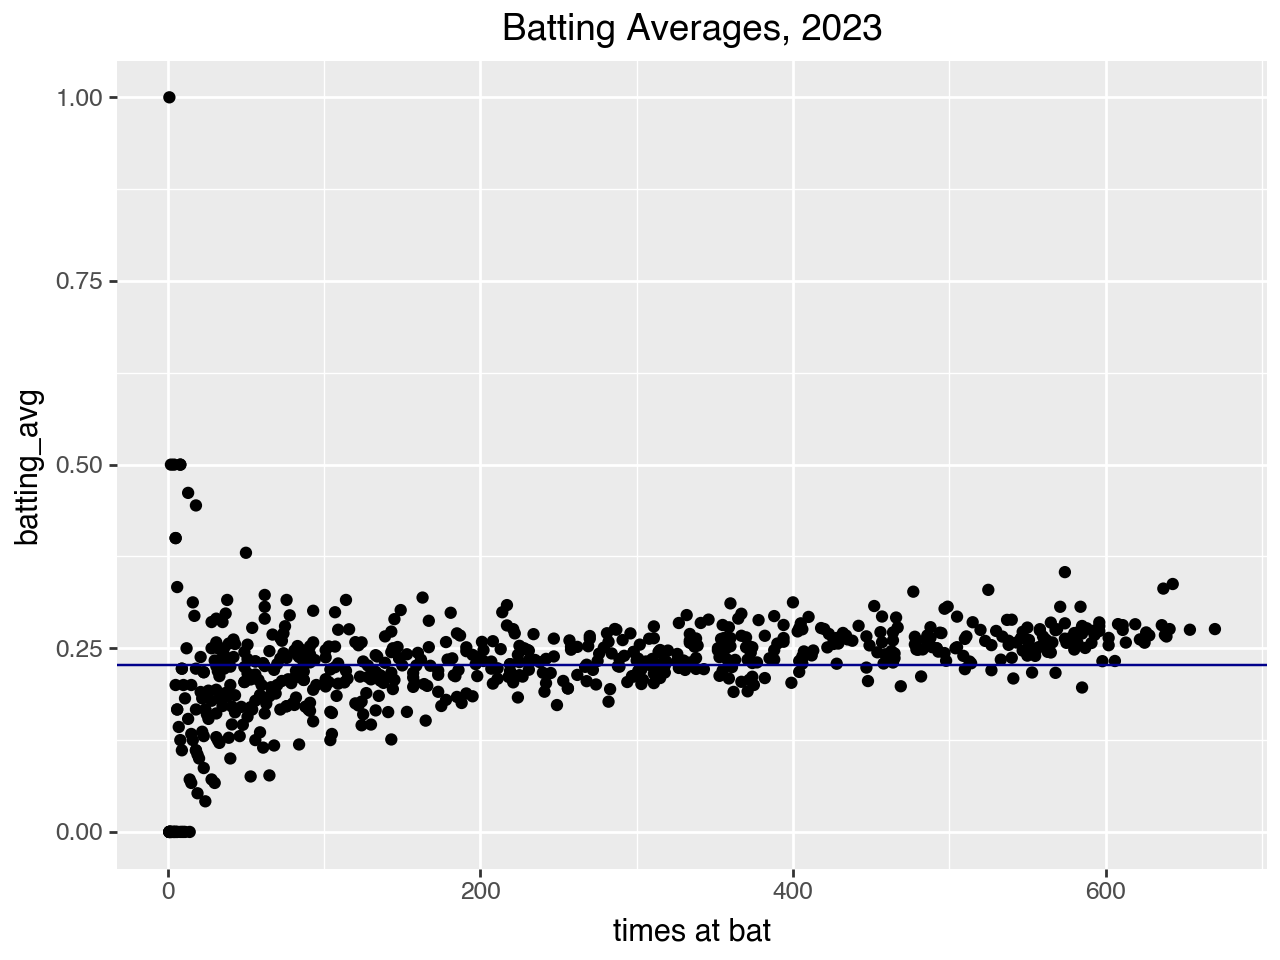

In [4]:
mean_ba = np.mean(battingf['batting_avg'])
(
    ggplot(battingf, aes(x="atbat", y="batting_avg")) +
    geom_point() + 
    geom_hline(yintercept = mean_ba, color="darkblue") + 
    scale_x_continuous(name = "times at bat") +  
    ggtitle("Batting Averages, 2023")
)

As you can see, the number of at-bats for players in 2023 varied widely; some players were up hundreds of times, and some fewer than ten times. 
For players with a lot of at-bats, their observed batting average is probabably a good estimate of their innate batting ability. But for players with fewer at-bats, their observed batting average is more likely to be an over or under estimate of their ability. 

We can make this point dramatically by trying to use our naive batting ability estimates to ask the question, **_Who are the top 10 batters_**?

In [5]:
naive_top10 = battingf.nlargest(10, 'batting_avg')
naive_top10

,playerID,atbat,hits,batting_avg
140,culbech01,1,1,1.000000
124,colliza01,4,2,0.500000
325,lopezal03,2,1,0.500000
450,perezmi03,8,4,0.500000
593,tuckeco01,8,4,0.500000
626,wallfo01,13,6,0.461538
583,toroab01,18,8,0.444444
165,downsje01,5,2,0.400000
229,graytr01,5,2,0.400000
121,clemeer01,50,19,0.380000


Do you trust this ranking? Probably not---notice that most of the players in the top ten using this naive measure have actually been at bat very few times, and their batting averages are unrealistically high. Remember: the average batting average in the league for this season is 0.23, and the standard deviation is small. Batting averages of 1.0 or even 0.5 are highly improbable estimates of actual player ability.

This is analogous to sorting the rankings of a product on an online shopping site. Which assessment would you consider more reliable: one with a five-star average rating calculated from only one or two ratings, or one with a 4.5 star rating calculated from 200 ratings? Personally, I would be more likely to trust the assesment of the second product.

Given that our observations of the players are so uneven, is there a better way estimate how good a batter each player really is?

We would like a method that handles players with very few observations in a reasonable way. If a player has been at bat only once, their observed batting average is either 1 or 0; either they look perfect, or they look terrible. Since they are most likely neither, we'd like to assume a reasonable estimate of their batting ability, one we can use while we are waiting for more data. And of course, we want a method where the estimate improves as more data becomes available.

## Estimating batting ability with probabilistic modeling

One approach that robustly handles players with few at-bats is *probabilistic modeling*. In this article, we will implement a probabilistic model for the batting ability problem using [Stan](https://mc-stan.org/). We won't explain the Stan code in depth, but we will try to explain what the model is doing.

The idea behind this model is that a player's empirical batting performance is merely an *observable approximation* of the player's *unobservable* "innate batting ability," which we'll define as the probability that a batter will make a hit when he or she is at bat. This is illustrated in the figure below.

![Model of Batting Process](batting_model.png)

**Caption: Our model of the batting process. An individual batter has a given (unobservable) batting ability, drawn from the distribution of batting abilities for the population. For the player's `n` at-bats, we observe the number of hits and misses during play.**

In order to estimate player batting ability, which we cannot directly observe, we will define a probabilistic process to "explain" the observable batting performance in terms of the unobservable player ability.

Specifically, we'll model each player as a coin, where a hit is "heads", and the number of at-bats is the number of flips. We'll call the (unknown) probability of coming up heads (getting a hit) `gamma`. Then we can model each player as a binomial:

```
hits_i ~ binomial(atbat_i, gamma_i)
```

In other words, `gamma` is the player's innate batting ability.

We'll further assume that the player `gamma`s are distributed around some (also unknown) "global player batting ability." The idea here is that all the players in some sense come from the same population, so their batting performances are somewhat similar. This implies that player batting abilities tend to cluster around some average batting ability, and very high (or low) abilities are unlikely. 

This is *only* an assumption, but we consider it plausible because of real-life observations like "batting averages for professional players tend to be around 0.25ish, and super high batting averages are unlikely"---an observation we can back up with the data.

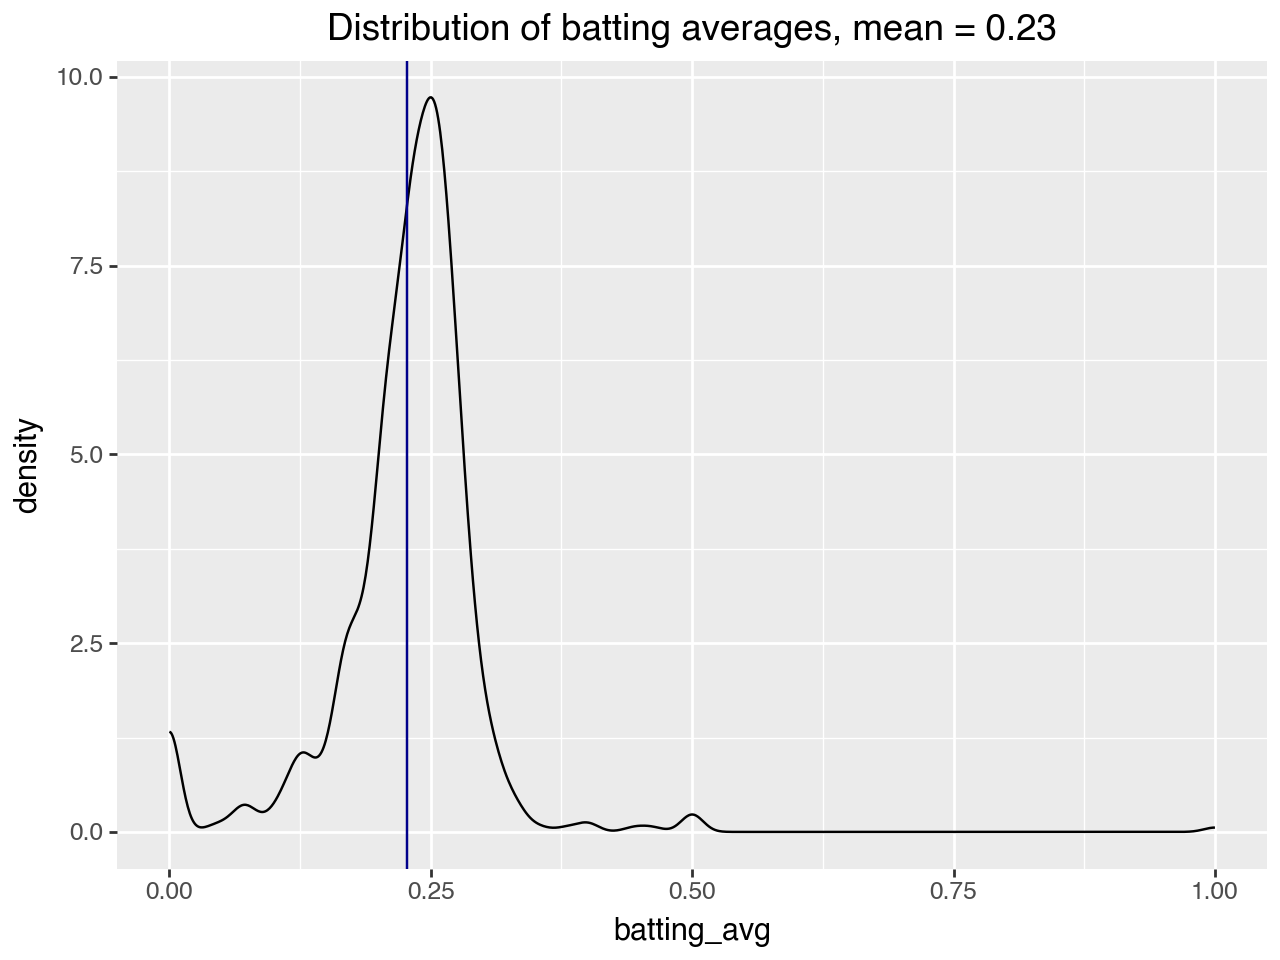

In [6]:
(
    ggplot(battingf, aes(x="batting_avg")) + 
    geom_density() + geom_vline(xintercept=mean_ba, color="darkblue") + 
    ggtitle(f"Distribution of batting averages, mean = {mean_ba:.2f}")
)

An advantage of probabilistic modeling is that it allows us to express such assumptions (or other plausible ones) and incorporate them into our analysis in a principled way. With more common frequentist analyses (like our naive approach), we don't have a way to express notions like "player abilities are in a tight, non-uniform distribution," without having to resort to ad-hoc rules such as "only consider batters who have more than 100 at-bats."

To continue: we want to model the "global player batting ability" as a distribution from which individual player gammas are drawn. Since the players are binomial, we'll assume that the gammas are distributed as a beta distribution. 

```
gamma ~ beta(a, b); 
```

In Bayesian parlance, the distribution `beta(a, b)` represents the *priors* on `gamma` (player batting ability). For a player with only a few at-bats, there is little information on their individual ability, so the model will estimate that their batting ability is near some average batting ability. For players with many at-bats, the model will have enough information to pull the estimate away from the grand mean.

Intuitively, the  parameters `a` and `b` represent `a` "pseudo-hits" for `a + b` "pseudo-atbats". The larger `a + b` is, the more observations will be required to pull a player's estimated ability away from the 
grand mean (`a/(a+b)`). In other words, this formulation smooths all the estimated batting averages towards some (estimated) grand mean. The quantity `a+b` specifies the strength of the smoothing.

We can control how much we smooth to the mean, and what the mean is, by explicitly picking `a` and `b`. In this model, however, we will use Stan to estimate `a` and `b` from the data.

Below is the code for the Stan model. Don't worry if you can't read it; the explanation above and the comments in the code should be sufficient.

In [7]:
stan_model_src = """
data {                                               // this block describes the training data
  int<lower=1> n_players;                            // number of players observed
  array[n_players] int<lower=0> hits;                // number of hits - needs to be integer type because of binomial call
  array[n_players] int<lower=0> atbat;               // number of at-bats - needs to be integer type because of binomial call
}
parameters {                                           // this block declares the parameters to be estimated
  vector<lower=0, upper=1>[n_players] gamma;           // unobserved "true" batting abilities
  real<lower=0> a;                                     // pseudo-hits
  real<lower=0> b;                                     // pseudo-misses
}
model {                                             // this block describes the relations between parameters and data
  gamma ~ beta(a, b);                               // distribution of unobservable batting ability
  hits ~ binomial(atbat, gamma);                    // relation of hits to per-player ability
}
"""
stan_file_name: str = standir + "batting_model.stan"
with open(stan_file_name, "w", encoding="utf8") as file:
    file.write(stan_model_src)

In [8]:
# build up Stan data

stan_data = {
    'n_players': battingf.shape[0],
    'hits': list(battingf['hits']),
    'atbat': list(battingf['atbat']),
}
data_file_name: str = stan_datadir + "batting_model.data.json"
with open(data_file_name, "w", encoding="utf8") as file:
    json.dump(stan_data, file)

In [9]:
model = CmdStanModel(stan_file=stan_file_name)
fit = model.sample(
    data=data_file_name,
    iter_warmup=1000,
    iter_sampling=1000,
    show_progress=True,
    show_console=False,
)
# get the samples
fit_Stan = fit.draws_pd().reset_index(drop=True, inplace=False)  # force copy just in case

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

Unlike most modeling systems, Stan does not return point estimates of the parameters it is trying to fit. It instead uses Monte Carlo sampling to jointly generate sets of parameters (called samples) that are consistent with the training data. Each of these samples (4000 of them, in this case) represents a "possible world" that could generate the observed data. We can use these possible worlds to not only calculate point estimates of the parameters we want, but also uncertainty ranges around those estimates.

Behind the scenes, we have fit the model, and saved Stan's generated samples into a data frame called `fit_Stan`. For all the details, see the source code linked at the top of this article.

In [10]:
fit_Stan.shape

(4000, 668)

## Estimate of the priors

Let's look at Stan's estimates for `a` and `b`. Do we get reasonable distributions of pseudo-observations and global batting ability?
How close are the batting ability estimates to the observed mean batting average?

As a diagnostic on the model, we would like to see that the distributions of both `a` and `b` are unimodal (which they are, but for brevity the plots are omitted). We'd also like to see that the mean of the beta distribution is near the observed mean batting average in every sample.

In [11]:
## check the a and b estimates. 

abframe = fit_Stan[['a', 'b']].copy()
abframe['pseudo_obsv'] = abframe['a'] + abframe['b']
abframe['global_ba'] = abframe['a']/abframe['pseudo_obsv']
abframe['variance'] = abframe['a']*abframe['b']/( abframe['pseudo_obsv']**2 * (abframe['pseudo_obsv'] + 1) )

print(f"""
      Mean pseudo observation estimate: {abframe['pseudo_obsv'].mean():.3f}; 
      Mean global batting ability estimate: {abframe['global_ba'].mean():.3f}, compared to observed mean batting average {mean_ba:.3f}
""")


      Mean pseudo observation estimate: 434.612; 
      Mean global batting ability estimate: 0.244, compared to observed mean batting average 0.227



In [12]:
ablong = pd.melt(abframe, id_vars=['a', 'b'], value_vars=['pseudo_obsv', 'global_ba'], var_name='parameter', value_name='value')
ablong

,a,b,parameter,value
0,104.669370,319.48666,pseudo_obsv,424.156030
1,111.407480,348.74689,pseudo_obsv,460.154370
2,110.370060,341.29248,pseudo_obsv,451.662540
3,107.387380,332.90207,pseudo_obsv,440.289450
4,119.354500,365.41653,pseudo_obsv,484.771030
...,...,...,...,...
7995,91.173963,280.66382,global_ba,0.245198
7996,92.759850,281.44318,global_ba,0.247886
7997,113.643650,355.19240,global_ba,0.242395
7998,136.494850,426.80543,global_ba,0.242313


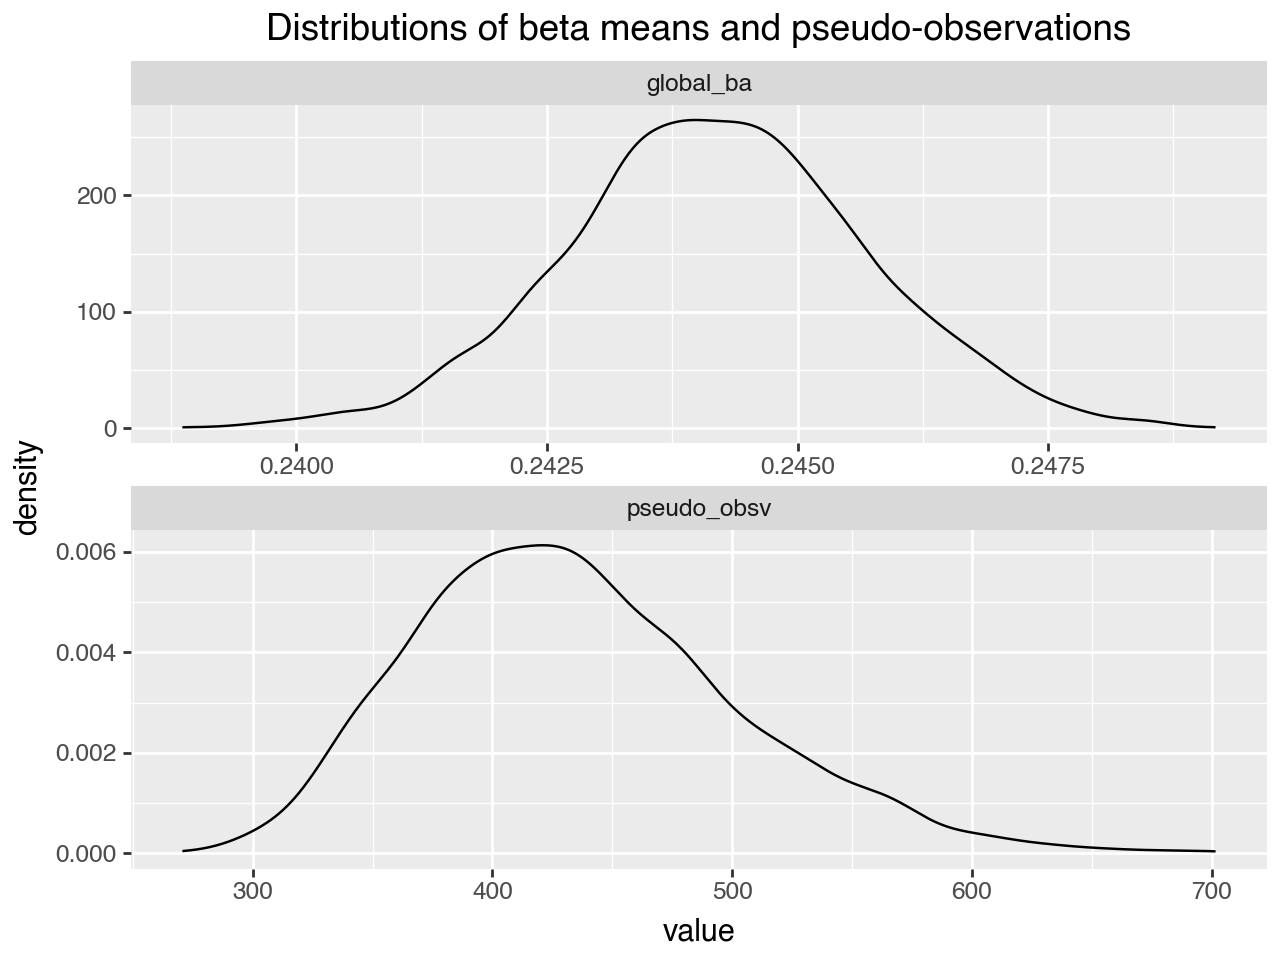

In [13]:
(
    ggplot(ablong, aes(x="value")) + 
    geom_density() + 
    facet_wrap("parameter", ncol=1, scales="free") + 
    ggtitle("Distributions of beta means and pseudo-observations")
)

The mean of beta is generally between 0.24 and 0.25, which is not far from the observed mean batting average of 0.23. 
The large number of pseudo-observations corresponds to beta distributions with fairly low variance, which is again consistent with our empirical observation. It also means that there will be a lot of smoothing on the estimates.

## Estimating batting ability

Now let's get all the samples of player gammas.

In [14]:
batting_estimates = fit_Stan.filter(like='gamma').copy()
batting_estimates.columns = battingf['playerID']
batting_estimates

playerID,abramcj01,abreujo02,abreuwi02,acunaro01,adamewi01,adamsjo03,adamsri03,adelljo01,adriaeh01,aguilje01,...,wongko01,wynnsau01,yastrmi01,yelicch01,yepezju01,yoshima02,youngja02,youngja03,zavalse01,zuninmi01
0,0.255413,0.248422,0.258750,0.308997,0.228818,0.211759,0.265923,0.274897,0.259137,0.261953,...,0.220038,0.241647,0.245046,0.272124,0.238759,0.256667,0.250985,0.253605,0.227349,0.222809
1,0.244398,0.217937,0.251756,0.298012,0.226152,0.250242,0.263700,0.227857,0.214193,0.218730,...,0.240816,0.225152,0.219763,0.250552,0.262038,0.270782,0.231036,0.283892,0.217628,0.237123
2,0.243953,0.258032,0.263147,0.296633,0.230742,0.226632,0.247227,0.247421,0.269358,0.253806,...,0.203861,0.248941,0.251303,0.272979,0.216841,0.269098,0.237922,0.208346,0.220289,0.219931
3,0.249291,0.242690,0.261040,0.310948,0.230661,0.217918,0.252185,0.240308,0.210836,0.209032,...,0.236880,0.244005,0.232859,0.252558,0.256763,0.282080,0.235101,0.265126,0.221886,0.227214
4,0.237667,0.251283,0.240370,0.290025,0.222474,0.273592,0.234023,0.246917,0.276008,0.246093,...,0.234033,0.215739,0.238712,0.277049,0.250354,0.255406,0.260344,0.233977,0.219615,0.237419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.259563,0.245729,0.300755,0.283800,0.231597,0.200734,0.234716,0.232010,0.214260,0.275272,...,0.185656,0.251413,0.217617,0.266569,0.245652,0.267713,0.245294,0.223936,0.206689,0.249676
3996,0.245689,0.236702,0.238916,0.310108,0.221121,0.232582,0.227642,0.251177,0.236613,0.234703,...,0.223121,0.239689,0.219973,0.265691,0.252382,0.282599,0.263229,0.249938,0.214311,0.234321
3997,0.224689,0.227445,0.234514,0.298208,0.253708,0.257946,0.258588,0.251793,0.232207,0.250513,...,0.210347,0.241315,0.242738,0.253043,0.242358,0.262545,0.221709,0.274076,0.252756,0.234653
3998,0.228148,0.233065,0.252618,0.311618,0.230439,0.235384,0.248815,0.229337,0.228540,0.230203,...,0.216087,0.207223,0.243261,0.244595,0.212859,0.285114,0.230973,0.233102,0.257751,0.235676


For every player, we can use the above set of Stan estimates to get a point estimate of their gamma (we'll use the mean; you can also use the median), and an uncertainty interval that covers 95% of the Stan estimates.

In [15]:

nplayers = battingf.shape[0]
means = [np.mean(batting_estimates.iloc[:, i]) for i in range(nplayers)]
# calculate the 95% uncertainty interval
intervals = [np.percentile(batting_estimates.iloc[:, i], [2.5, 97.5]) for i in range(nplayers)]
interval_bottom = [interv[0] for interv in intervals]
interval_top = [interv[1] for interv in intervals]

battingf['gamma'] = means
battingf['g_min'] = interval_bottom
battingf['g_max'] = interval_top

battingf



,playerID,atbat,hits,batting_avg,gamma,g_min,g_max
0,abramcj01,563,138,0.245115,0.244644,0.217479,0.271896
1,abreujo02,540,128,0.237037,0.240080,0.212640,0.266951
2,abreuwi02,76,24,0.315789,0.254437,0.215732,0.295471
3,acunaro01,643,217,0.337481,0.300198,0.271661,0.330569
4,adamewi01,553,120,0.216998,0.228769,0.202451,0.256487
...,...,...,...,...,...,...,...
651,yoshima02,537,155,0.288641,0.268467,0.240529,0.297654
652,youngja02,43,8,0.186047,0.238932,0.201439,0.278378
653,youngja03,107,27,0.252336,0.245744,0.209507,0.283893
654,zavalse01,175,30,0.171429,0.223203,0.190155,0.258194


Here is the roster of top 10 batters, according to the Stan point estimates. Notice that all the players in this roster have been at bat hundreds of times, so we can consider this top 10 to be more trustworthy. 

In [16]:
stan_top10 = battingf.nlargest(10, 'gamma')
stan_top10.loc[:, ['playerID', 'atbat', 'hits', 'batting_avg', 'gamma', 'g_min', 'g_max']]

,playerID,atbat,hits,batting_avg,gamma,g_min,g_max
34,arraelu01,574,203,0.353659,0.306837,0.278873,0.336221
3,acunaro01,643,217,0.337481,0.300198,0.271661,0.330569
200,freemfr01,637,211,0.331240,0.296087,0.268344,0.324402
158,diazya01,525,173,0.329524,0.291116,0.262371,0.321038
520,seageco01,477,156,0.327044,0.287488,0.258570,0.318180
61,bettsmo01,584,179,0.306507,0.280108,0.253704,0.307470
62,bichebo01,571,175,0.306480,0.279565,0.252326,0.307508
53,bellico01,499,153,0.306613,0.277572,0.249387,0.306813
469,ramirha02,400,125,0.312500,0.277267,0.247371,0.310371
410,naylojo01,452,139,0.307522,0.276918,0.247745,0.308113


Let's plot the top 10 players' gammas, along with their observed batting average and the estimated global mean batting ability.


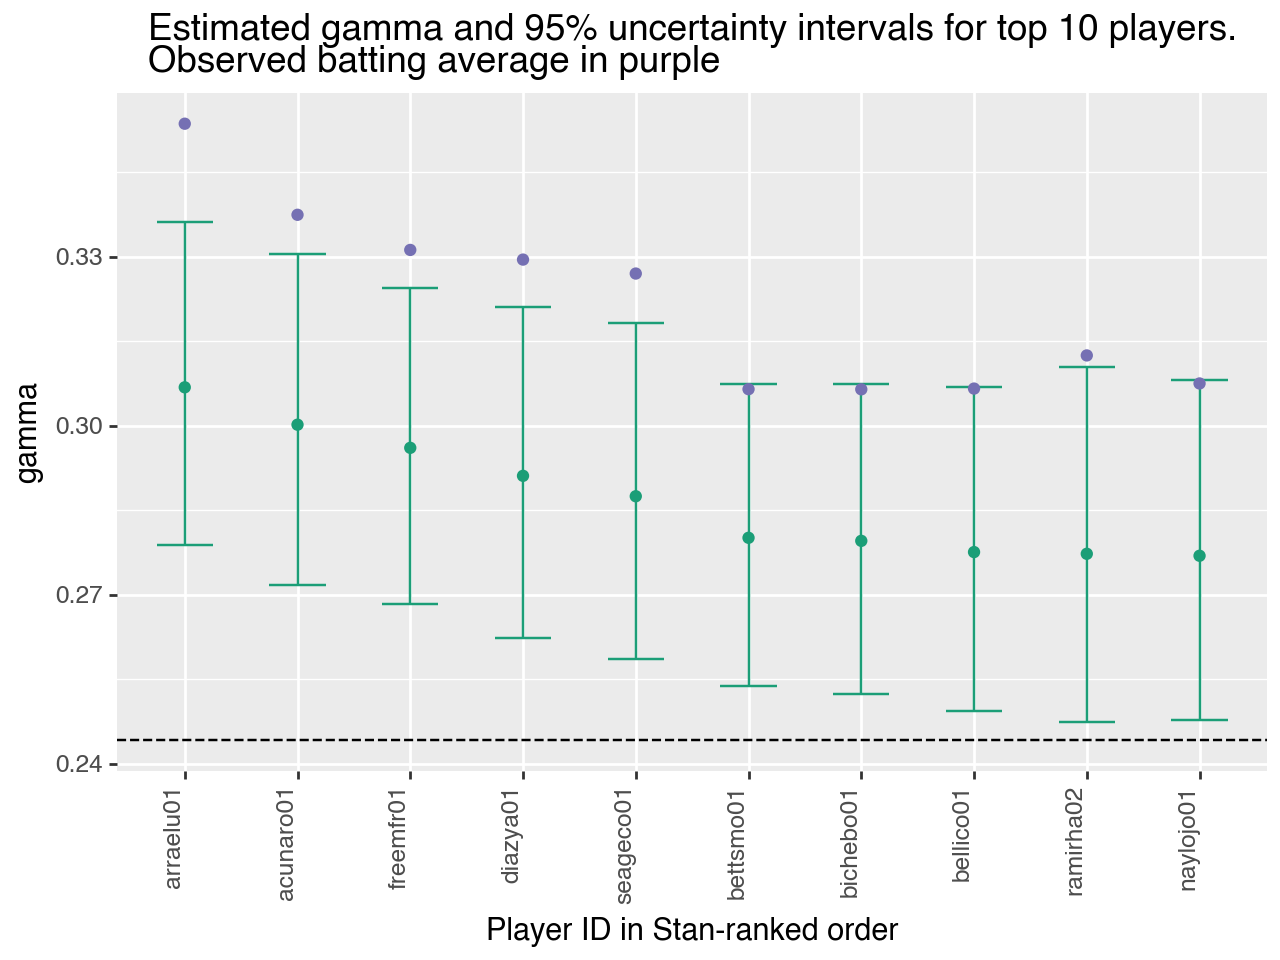

In [17]:
global_ba = abframe['global_ba'].mean()

(
    ggplot(stan_top10, aes(x = "reorder(playerID, -gamma)")) + 
    geom_errorbar(aes(ymin="g_min", ymax="g_max"),color="#1b9e77" ) +
    geom_point(aes(y = "gamma"), color="#1b9e77") + 
    geom_point(aes(y = "batting_avg"), color="#7570b3") + 
    geom_hline(yintercept = global_ba, linetype="dashed") + 
    theme(axis_text_x=element_text(angle=90, hjust=1)) + 
    labs(x="Player ID in Stan-ranked order") + 
    ggtitle(f"Estimated gamma and 95% uncertainty intervals for top 10 players.\nObserved batting average in purple")
)

You might wonder why the observed batting averages are consistently so much higher than the estimated batting abilities. This is because the model is smoothing all the estimates towards the priors. Hence, performance estimates for high performing batters will be biased down, and performance estimates for low performing batters will be biased up. This is not a property unique to Stan; it is a property of the smoothing process.

It is also worth pointing out, however, that the uncertainty intervals are away from the estimated global mean (horizontal dashed line), indicating that the model identifies these players as having above average batting ability. Furthermore, the ranking order of the players according to their gamma estimates is generally consistent with the ranking of their empirical batting averages.

What about the players with very few at-bats? As desired, their gammas are near the estimated global mean of 0.24.

In [18]:
battingf.loc[battingf['atbat']<=5, ['playerID', 'atbat', 'hits', 'batting_avg', 'gamma', 'g_min', 'g_max']]

,playerID,atbat,hits,batting_avg,gamma,g_min,g_max
46,barretr01,2,0,0.0,0.243261,0.204423,0.284172
111,castidi02,1,0,0.0,0.243484,0.202068,0.287601
124,colliza01,4,2,0.5,0.246683,0.206278,0.288201
140,culbech01,1,1,1.0,0.245780,0.207254,0.286393
165,downsje01,5,2,0.4,0.246108,0.206405,0.287695
205,fulmemi01,1,0,0.0,0.243642,0.205138,0.284218
229,graytr01,5,2,0.4,0.245800,0.205371,0.288453
242,hamilbi02,2,0,0.0,0.243317,0.205493,0.283204
243,hamilca01,5,0,0.0,0.241302,0.203104,0.282519
290,kaiseco01,4,0,0.0,0.241975,0.202445,0.282454


## Who's the best player? Another way to choose

If our goal is in fact to choose the player(s) with the highest batting ability, there is another way to do it, using the "possible worlds" sampled by Stan. For each one of the 4000 possible worlds, we identify the highest ability player. The "true" best player is most likely the one who is best in the most possible worlds.

Below, we find the best player in every Stan sample, and pick our top 10 accordingly. We could of course pick the top 10 in each possible world, and draw our "most likely top 10" from the resulting sets, but picking the single best is easier to code, and gets the point across.

In [19]:
# get the best performance in each sample world
best_perf = batting_estimates.max(axis=1)

# mark which player was the best in each world. ties ok
is_best = batting_estimates.eq(best_perf, axis=0).astype(int) 

mean_best = is_best.mean().reset_index() # compute the series and convert it to a data frame
mean_best.columns = ['playerID', 'frac_as_best']

# join it into battingf
battingf = battingf.merge(mean_best, on='playerID')
battingf


,playerID,atbat,hits,batting_avg,gamma,g_min,g_max,frac_as_best
0,abramcj01,563,138,0.245115,0.244644,0.217479,0.271896,0.00000
1,abreujo02,540,128,0.237037,0.240080,0.212640,0.266951,0.00000
2,abreuwi02,76,24,0.315789,0.254437,0.215732,0.295471,0.00175
3,acunaro01,643,217,0.337481,0.300198,0.271661,0.330569,0.18100
4,adamewi01,553,120,0.216998,0.228769,0.202451,0.256487,0.00000
...,...,...,...,...,...,...,...,...
651,yoshima02,537,155,0.288641,0.268467,0.240529,0.297654,0.00150
652,youngja02,43,8,0.186047,0.238932,0.201439,0.278378,0.00050
653,youngja03,107,27,0.252336,0.245744,0.209507,0.283893,0.00025
654,zavalse01,175,30,0.171429,0.223203,0.190155,0.258194,0.00000


In [20]:
# top 10 by fraction best
top10_by_frac = battingf.nlargest(10, 'frac_as_best')
top10_by_frac[['playerID', 'frac_as_best', 'batting_avg', 'gamma']]

,playerID,frac_as_best,batting_avg,gamma
34,arraelu01,0.33250,0.353659,0.306837
3,acunaro01,0.18100,0.337481,0.300198
200,freemfr01,0.11000,0.331240,0.296087
158,diazya01,0.06425,0.329524,0.291116
520,seageco01,0.04150,0.327044,0.287488
469,ramirha02,0.01650,0.312500,0.277267
62,bichebo01,0.01250,0.306480,0.279565
410,naylojo01,0.01075,0.307522,0.276918
61,bettsmo01,0.01050,0.306507,0.280108
53,bellico01,0.00975,0.306613,0.277572


This is substantially the same set of players as were selected by looking just at the point estimates. That's good! It gives us confidence that these are indeed the players with the highest batting ability.

Let's mark the players who show up in the top 10, by either criterion.

In [21]:
top10_by_frac = set(battingf.nlargest(10, 'frac_as_best')['playerID'])
top10_by_gamma = set(battingf.nlargest(10, 'gamma')['playerID'])

# take a look at the differences in the sets
print(f'Picked by point estimate but not by fraction best: { top10_by_gamma.difference(top10_by_frac) }')
print(f'Picked by fraction best but not by point estimate: { top10_by_frac.difference(top10_by_gamma) }')

in_top10_set =  top10_by_gamma.union(top10_by_frac)
in_top10 = battingf['playerID'].isin(in_top10_set)

battingf['in_top10'] = in_top10.astype(str)
battingf.loc[battingf['in_top10']=='True', ['playerID', 'atbat', 'hits', 'batting_avg', 'gamma', 'frac_as_best']]

Picked by point estimate but not by fraction best: set()
Picked by fraction best but not by point estimate: set()


,playerID,atbat,hits,batting_avg,gamma,frac_as_best
3,acunaro01,643,217,0.337481,0.300198,0.18100
34,arraelu01,574,203,0.353659,0.306837,0.33250
53,bellico01,499,153,0.306613,0.277572,0.00975
61,bettsmo01,584,179,0.306507,0.280108,0.01050
62,bichebo01,571,175,0.306480,0.279565,0.01250
158,diazya01,525,173,0.329524,0.291116,0.06425
200,freemfr01,637,211,0.331240,0.296087,0.11000
410,naylojo01,452,139,0.307522,0.276918,0.01075
469,ramirha02,400,125,0.312500,0.277267,0.01650
520,seageco01,477,156,0.327044,0.287488,0.04150


Now let's plot all the players, sorted by observed batting average (lowest to highest). We'll plot the estimated player ability (`gamma`), along with the 95% uncertainty intervals around the estimates (in light gray).
The points are also color coded by whether or not the player made at least one of the top 10 lists (in green) or not (in purple). The dashed line is the estimated mean player ability.

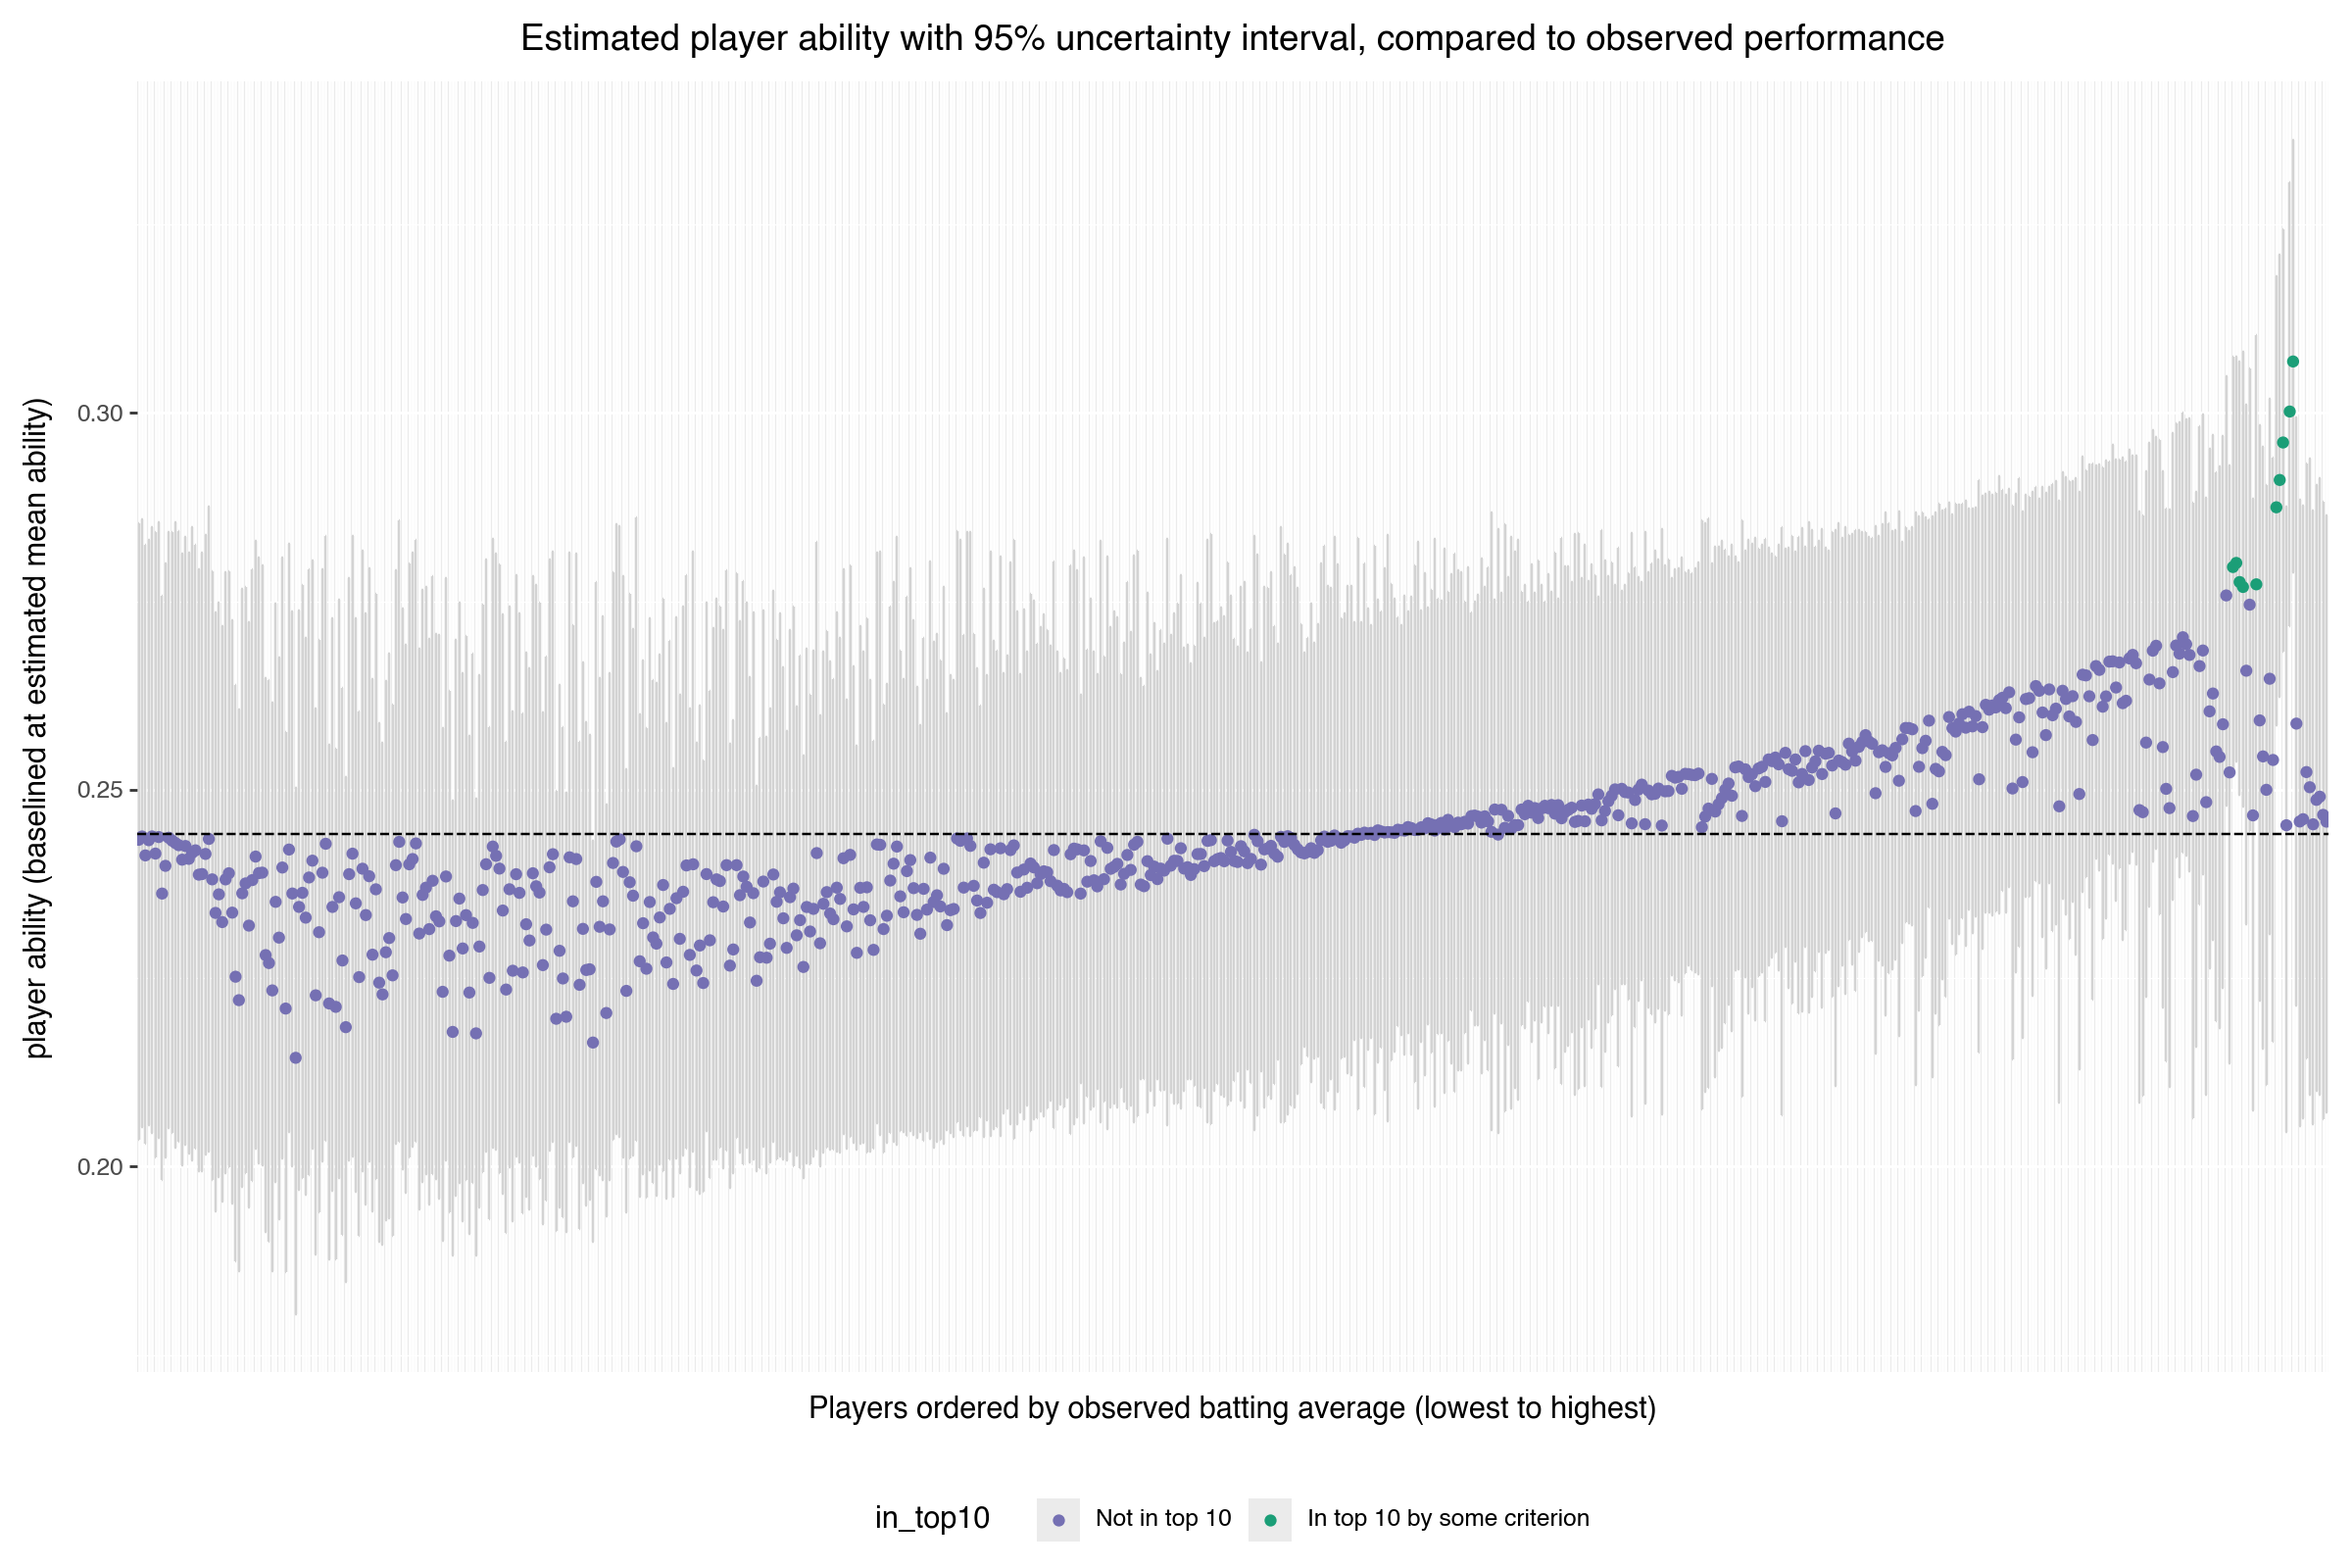

In [22]:

palette = {
    'False':'#7570b3',
    'True': '#1b9e77'
}

labels = {
    'False': 'Not in top 10',
    'True': 'In top 10 by some criterion'
}

(
    ggplot(battingf, aes(x = "reorder(playerID, batting_avg)")) + 
    geom_errorbar(aes(ymin="g_min", ymax="g_max"), color='lightgray' ) +
    geom_point(aes(y = "gamma", color='in_top10')) + 
    geom_hline(yintercept = global_ba, linetype="dashed") + 
    labs(x="Players ordered by observed batting average (lowest to highest)", y="player ability (baselined at estimated mean ability)") + 
    ggtitle(f"Estimated player ability with 95% uncertainty interval, compared to observed performance") + 
    scale_color_manual(values=palette, labels=labels) +
    theme(figure_size = (12, 8), legend_position='bottom', axis_text_x=element_blank(), axis_ticks_x=element_blank())
)



There are a few things to note in this graph. First, the ranking of ability estimates roughly correlate with the ranking of observed batting averages, as desired. There is a cluster of purple players to the right of the green players who have relatively low (actually, average) estimated batting ability, but high observed batting average. These are the players who weren't at bat very often, but who were successful when they were. The model did not have enough data on these players to move the ability estimates away from the prior. Similarly, there are players at the far left of the graph who cluster around the mean, even though their observed batting averages are zero, or nearly so. These are also players with only a few at bats, so their estimated abilities still smooth strongly into the prior.

So if the goal of estimating player ability is to identify the best players, then this model has been able to do so. It automatically discounts spurious empirical estimates that are likely inaccurate due to insufficient data, without the analyst having to specify what "insufficient data" is in an ad-hoc way. It also provides reasonable assumptions about the abilities of low information (low at-bat) players---assumptions that are based on the population data.

## Matching the model to reality

In [23]:
battingf.nlargest(3, 'frac_as_best')[['playerID', 'frac_as_best', 'batting_avg', 'gamma']]

,playerID,frac_as_best,batting_avg,gamma
34,arraelu01,0.3325,0.353659,0.306837
3,acunaro01,0.1810,0.337481,0.300198
200,freemfr01,0.1100,0.331240,0.296087


Stan's selected best-ranked player by both "probability of being best" and point estimate criteria, `arraelu01`, is player Luis Arráez. Here's what his [Wikipedia page](https://en.wikipedia.org/wiki/Luis_Arr%C3%A1ez) has to say about him:

> Known for his ability to put the ball in play and not striking out, Arráez is considered one of the best contact hitters of his generation. From 2022 to 2024, Arráez became the first player in MLB history to win three consecutive batting titles with three different teams.... He was also the second player in the modern era to win a batting title in each league and the first to do so in consecutive years. 

Note that his career MLB batting average[^3] (calculated from 2019 through May 17, 2026) is 0.317. This is pretty close to our estimated `gamma` of 0.307. In fact, our estimate is a better prediction of Arráez's career performance (so far) than the simple observation of his 2023 season batting average is---even though we estimated his ability using only this single season!

The next two players (as ranked by probability of being best) are Ronald Acuña, Jr. (career batting average so far = 0.288) and Freddie Freeman (career batting average so far = 0.299). Again, both Stan's estimates and career batting averages for all these players are below their observed 2023 season batting averages---showing that smoothing performance estimates to the population mean was a reasonable modeling choice. Note also that the career batting averages for these top three players also fell within the 95% uncertainty intervals of ability, as estimated by Stan. 


[^3]: All career batting averages as given by Wikipedia on May 19, 2026.

## Matching Summaries

Let's further compare Stan's batting ability estimates with observations from the data.

In [24]:
mean_ability = battingf['gamma'].mean()
std_ability = battingf['gamma'].std()

print(f'Mean observed batting average: {mean_ba:.3f}, standard deviation {std_ba:.3f}.')
print(f'Mean estimated batting ability: {mean_ability:.3f}, standard deviation {std_ability:.3f}.')

Mean observed batting average: 0.227, standard deviation 0.075.
Mean estimated batting ability: 0.244, standard deviation 0.012.


As we saw previously, Stan's estimated mean batter ability is close to what was observed in the data, but the standard deviation of the ability estimates is much lower! 
This is not surprising: we also know that the number of player at-bats varied widely, and players with few at-bats will have observed batting averages that will tend to over- or under- estimate their actual abilities. This is why observed batting average standard deviation is so much higher than estimated batting ability standard deviation.

In order to properly compare Stan's ability estimates to actual observations, we have to simulate the season in each Stan sample. That is, in each possible world, we give each player the same number of at-bats as they had in 2023, and generate a plausible observed batting average, given that number of at-bats. This is shown below.

In [25]:
def draw_synthetic_hitrate (atbat, bavec):
    return rng.binomial(atbat, bavec)/atbat

synthetic_hitrate_frame = pd.DataFrame({
    col: draw_synthetic_hitrate(battingf['atbat'][i], batting_estimates[col])
    for i, col in enumerate(batting_estimates.columns)
})

synthetic_hitrate_frame

,abramcj01,abreujo02,abreuwi02,acunaro01,adamewi01,adamsjo03,adamsri03,adelljo01,adriaeh01,aguilje01,...,wongko01,wynnsau01,yastrmi01,yelicch01,yepezju01,yoshima02,youngja02,youngja03,zavalse01,zuninmi01
0,0.243339,0.246296,0.381579,0.345257,0.235081,0.205128,0.286713,0.327586,0.1,0.288462,...,0.254464,0.276923,0.209091,0.256364,0.250000,0.216015,0.255814,0.177570,0.245714,0.250000
1,0.257549,0.209259,0.368421,0.317263,0.218807,0.333333,0.188811,0.224138,0.2,0.211538,...,0.223214,0.207692,0.221212,0.285455,0.216667,0.260708,0.232558,0.261682,0.228571,0.169355
2,0.238011,0.262963,0.210526,0.318818,0.209765,0.205128,0.328671,0.275862,0.4,0.240385,...,0.223214,0.307692,0.248485,0.260000,0.250000,0.275605,0.186047,0.224299,0.200000,0.266129
3,0.282416,0.253704,0.276316,0.284603,0.260398,0.256410,0.244755,0.241379,0.4,0.221154,...,0.245536,0.284615,0.193939,0.232727,0.300000,0.279330,0.279070,0.214953,0.291429,0.225806
4,0.218472,0.237037,0.236842,0.272162,0.231465,0.205128,0.223776,0.293103,0.8,0.163462,...,0.200893,0.184615,0.248485,0.270909,0.216667,0.240223,0.232558,0.214953,0.211429,0.209677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.289520,0.227778,0.421053,0.284603,0.215190,0.205128,0.279720,0.172414,0.0,0.211538,...,0.214286,0.238462,0.203030,0.270909,0.316667,0.277467,0.209302,0.224299,0.234286,0.241935
3996,0.253996,0.229630,0.381579,0.293935,0.222423,0.307692,0.209790,0.172414,0.2,0.307692,...,0.156250,0.223077,0.203030,0.281818,0.166667,0.305400,0.209302,0.233645,0.217143,0.225806
3997,0.236234,0.216667,0.250000,0.306376,0.227848,0.307692,0.181818,0.224138,0.5,0.192308,...,0.218750,0.253846,0.242424,0.270909,0.266667,0.249534,0.209302,0.252336,0.188571,0.241935
3998,0.275311,0.251852,0.236842,0.295490,0.216998,0.256410,0.195804,0.206897,0.0,0.173077,...,0.245536,0.230769,0.248485,0.252727,0.200000,0.324022,0.186047,0.196262,0.360000,0.266129


In [26]:
# get the mean and standard devation on ability for each sample world
mean_synth_vec = synthetic_hitrate_frame.mean(axis=1)
std_synth_vec = synthetic_hitrate_frame.std(axis=1)

# get the average mean and standard deviation over all sample worlds.
mean_synth = mean_synth_vec.mean()
std_synth = std_synth_vec.mean()

print(f'Mean observed batting average: {mean_ba:.3f}, standard deviation {std_ba:.3f}.')
print(f'Mean synthetic batting average observations: {mean_synth:.3f}, standard deviation {std_synth:.3f}.')


Mean observed batting average: 0.227, standard deviation 0.075.
Mean synthetic batting average observations: 0.244, standard deviation 0.078.


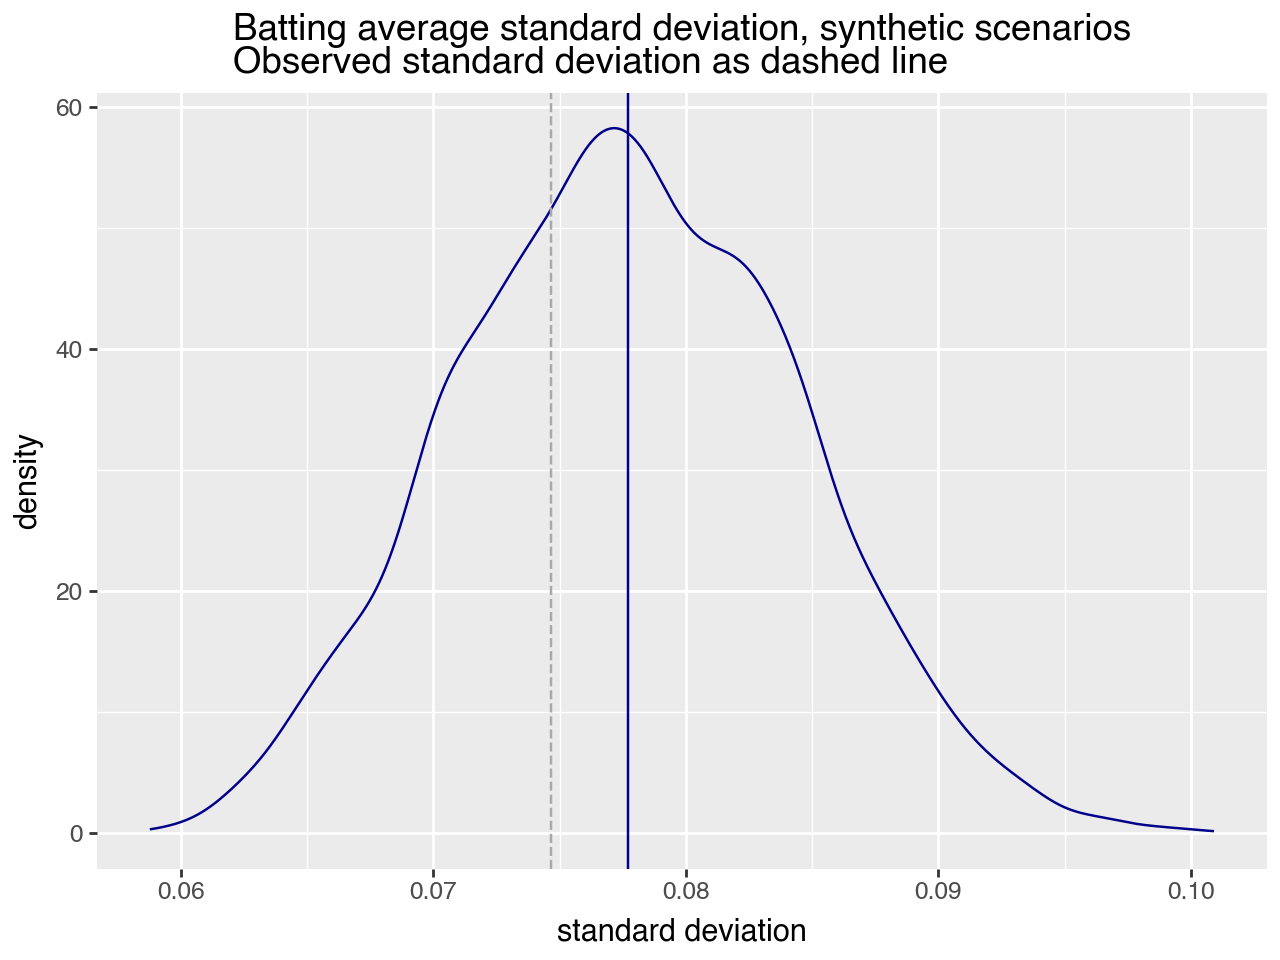

In [27]:
(
    ggplot(std_synth_vec.to_frame(name="standard deviation"), aes(x="standard deviation")) + 
    geom_density(color="darkblue") + 
    geom_vline(xintercept = std_synth, color="darkblue") + 
    geom_vline(xintercept=std_ba, color="darkgray", linetype="dashed") + 
    ggtitle("Batting average standard deviation, synthetic scenarios\nObserved standard deviation as dashed line")
)

Once we simulate the at-bats, the behaviors in the synthetic worlds are consistent with what was observed in the actual data. This also gives us confidence that our model is a reasonable approximation of the real world baseball hit generation process. Specifically, it's an approximation we can use to answer the questions we want to ask, like "who are the best batters?".

## Estimate what you want to know, not just what you can observe

As we've seen in the above example, an advantage of probabilistic modeling is that the analyst is able to distinguish between *observations* and (potentially unobservable) *quantities of interest*. If you, the analyst, can describe a probabilistic process that relates *what you can see* to *what you actually need to know*, then probabilistic modeling programs like Stan can estimate these quantities for you. By specifying the process to describe your problem and your task goal, you can add in prior knowledge or assumptions about the domain in a principled, documentable way, without having to resort to ad-hoc tweaks or data processing. 

In addition, probabilistic modeling systems that are based on Monte Carlo sampling (like Stan) provide samples of "possible worlds" that are consistent with the training data. You can use these samples not only to calculate point estimates of quantities of interest, but also uncertainty intervals around those estimates. You can also use the possible worlds to run simulations and scenarios (like, "who are the top 10 players in each possible world?") to further help you in decision-making. 

Of course, the estimates can only be as good as the process that you describe. But as your understanding of and intuitions about these processes improve, then so, too, can your model. 